 Loading and Inspecting the Dataset

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/Tesla - Deaths.csv")

# View basic structure and data types
df.info()

# Preview the first few rows
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 24 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Case #                                                                294 non-null    float64
 1   Year                                                                  294 non-null    float64
 2   Date                                                                  294 non-null    object 
 3    Country                                                              294 non-null    object 
 4    State                                                                294 non-null    object 
 5    Description                                                          295 non-null    object 
 6    Deaths                                                               299 non-null    float64
 7  

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,...,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN
3,291.0,2022.0,12/22/2022,USA,GA,Tesla crashes and burns,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN,NaN,NaN
4,290.0,2022.0,12/19/2022,Canada,-,Tesla crashes into storefront,1.0,-,-,-,...,-,-,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN,NaN,NaN


Data Cleaning

In [ ]:
# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop columns that are not useful for analysis
df.drop(columns=['Case#', 'Source', 'Note'], inplace=True, errors='ignore')

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Check for missing values
print(df.isnull().sum())


Case #                                                                    9
Year                                                                      9
Date                                                                      9
 Country                                                                  9
 State                                                                    9
 Description                                                              8
 Deaths                                                                   4
 Tesla driver                                                             9
 Tesla occupant                                                          13
 Other vehicle                                                            8
 Cyclists/ Peds                                                           7
 TSLA+cycl / peds                                                         6
 Model                                                                    7
 Autopilot c

In [ ]:
# Remove leading/trailing whitespaces from all column names
df.columns = df.columns.str.strip()


Events by Year, State, and Country


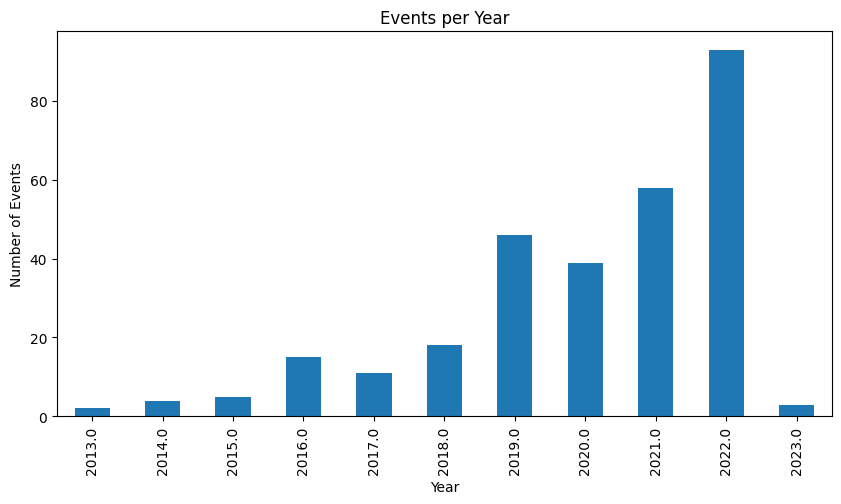

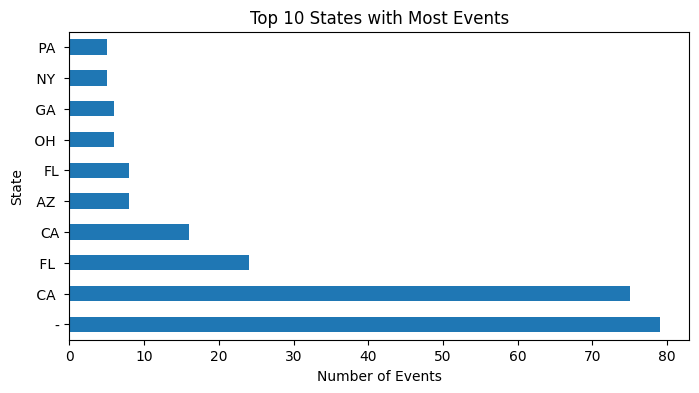

In [ ]:
import matplotlib.pyplot as plt

# Extract year from date
df['Year'] = df['Date'].dt.year

# Events per year
df['Year'].value_counts().sort_index().plot(kind='bar', title='Events per Year', figsize=(10,5))
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.show()

# Events per state (top 10)
df['State'].value_counts().head(10).plot(kind='barh', title='Top 10 States with Most Events', figsize=(8,4))
plt.xlabel('Number of Events')
plt.ylabel('State')
plt.show()


 Death and Victim Analysis

In [ ]:
# Descriptive stats for deaths
print(df['Deaths'].describe())

# Count how many times Tesla drivers died
print(df['Tesla driver'].value_counts())

# Proportion of events with at least one death
proportion_with_death = (df['Deaths'] > 0).mean()
print(f"Proportion of events with 1+ deaths: {proportion_with_death:.2%}")


count     299.000000
mean       10.284281
std       119.032014
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max      2013.000000
Name: Deaths, dtype: float64
Tesla driver
 -        172
  1       117
  28        1
  89        1
  117       1
  6         1
2014        1
Name: count, dtype: int64
Proportion of events with 1+ deaths: 98.68%


Autopilot and Model-Based Study

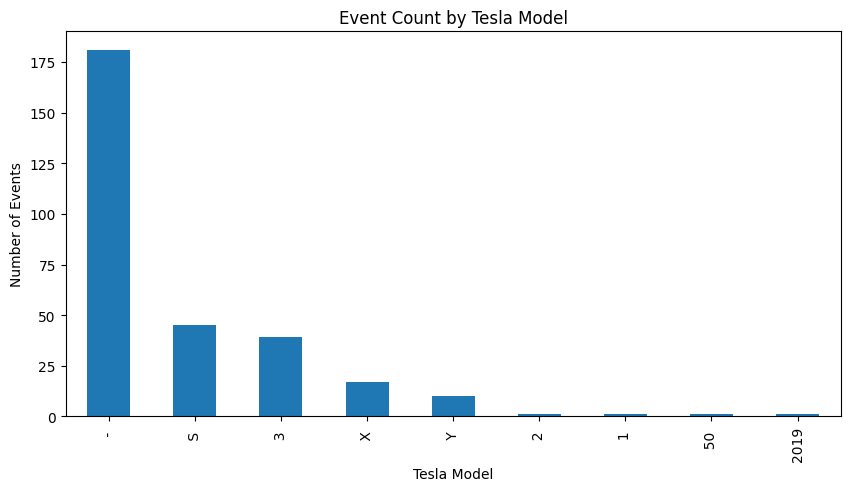

Autopilot claimed
 -       241
  1       32
  2        3
  8        1
  30       1
  38       1
  47       1
2020       1
Name: count, dtype: int64


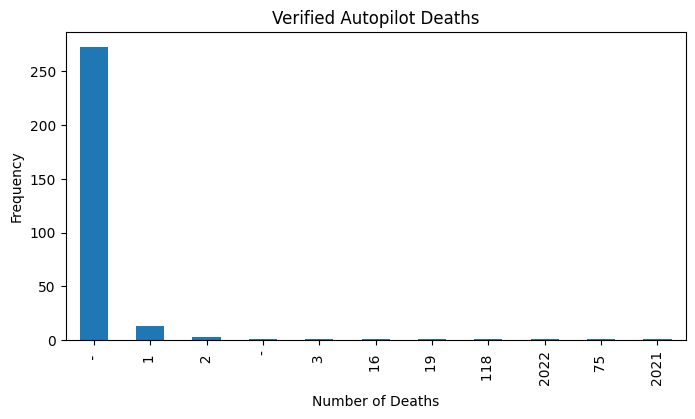

In [ ]:
# Events count by Tesla model
df['Model'].value_counts().plot(kind='bar', title='Event Count by Tesla Model', figsize=(10,5))
plt.xlabel('Tesla Model')
plt.ylabel('Number of Events')
plt.show()

# Frequency of autopilot being claimed
print(df['Autopilot claimed'].value_counts())

# Verified Tesla Autopilot Deaths analysis
df['Verified Tesla Autopilot Deaths'].value_counts().plot(kind='bar', title='Verified Autopilot Deaths', figsize=(8,4))
plt.xlabel('Number of Deaths')
plt.ylabel('Frequency')
plt.show()


Analysing with Correlation map

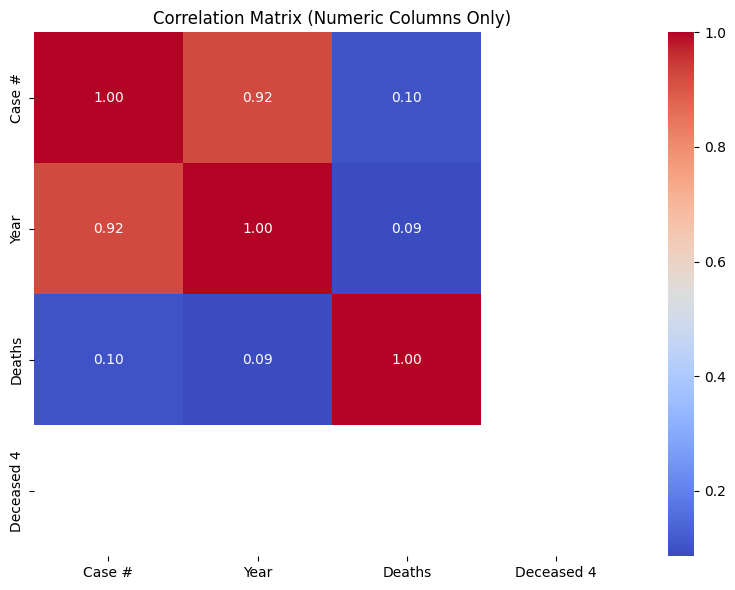

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Clean column names (if not done already)
df.columns = df.columns.str.strip()

# Convert non-numeric 'Year' and 'Deaths' to numeric if needed
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Deaths'] = pd.to_numeric(df['Deaths'], errors='coerce')

# Compute correlation matrix for numeric columns only
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Numeric Columns Only)")
plt.tight_layout()
plt.show()
